In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [13]:
dataset1 = pd.read_csv('/content/drive/MyDrive/_dl - Sheet1.csv')
X = dataset1[['inputs']].values
y = dataset1[['outputs']].values

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [29]:
dataset1.head()

,inputs,outputs
0,4,30
1,6,26
2,2,31
3,3,39
4,7,34


In [15]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [17]:
# Name:Bhuvaneshwaran H
# Register Number:212223240018
class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1,8)
        self.fc2 = nn.Linear(8,10)
        self.fc3 = nn.Linear(10,1)
        self.relu = nn.ReLU()
        self.history = {'loss':[]}

  def forward(self,x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x


In [18]:
lig = NeuralNet()
criterion = nn.MSELoss()
optimizer = optim.RMSprop (lig. parameters(),lr=0.001)

In [20]:
# Name:Bhuvaneshwaran H
# Register Number:212223240018
def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
  for epoch in range (epochs):
    optimizer. zero_grad()
    loss = criterion(ai_brain(X_train),y_train)
    loss. backward()
    optimizer.step()
    lig.history['loss'].append(loss.item())
    if epoch % 200 == 0:
      print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')

In [22]:
train_model(lig, X_train_tensor, y_train_tensor, criterion, optimizer)


Epoch [0/2000], Loss: 894.706177
Epoch [200/2000], Loss: 583.549194
Epoch [400/2000], Loss: 198.754425
Epoch [600/2000], Loss: 90.685104
Epoch [800/2000], Loss: 77.030777
Epoch [1000/2000], Loss: 67.309578
Epoch [1200/2000], Loss: 62.371101
Epoch [1400/2000], Loss: 61.341057
Epoch [1600/2000], Loss: 61.324501
Epoch [1800/2000], Loss: 61.333015


In [23]:
with torch.no_grad():
    test_loss = criterion(lig(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')


Test Loss: 11.404355


In [25]:
loss_df = pd.DataFrame(lig.history)

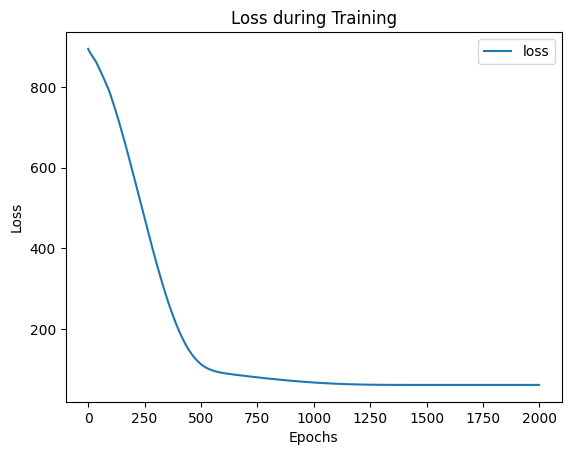

In [26]:
import matplotlib.pyplot as plt
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [28]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = lig(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 29.2089786529541
